In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [219]:
df = pd.read_stata("../data/data.dta")
df["w2_surveyed"]

C:\Users\mdmah\AppData\Local\Temp\ipykernel_44608\370835828.py:1: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  df = pd.read_stata("../data/data.dta")


0       yes
1       yes
2       yes
3       yes
4       yes
       ... 
3505     no
3506     no
3507     no
3508     no
3509     no
Name: w2_surveyed, Length: 3510, dtype: category
Categories (2, object): ['no' < 'yes']

In [220]:
print(df["w2_surveyed"].value_counts(dropna=False))
print(df["w3_surveyed"].value_counts(dropna=False))

w2_surveyed
yes    2107
no     1403
Name: count, dtype: int64
w3_surveyed
no     1788
yes    1722
Name: count, dtype: int64


In [221]:
cols = [
    "caseid_new",
    "w1_q34",
    "w2_rel_qual_combo",
    "w3_rel_qual",
    "w3_same_sex_couple",
    "w2_surveyed",
    "w3_surveyed",
    "w3_attrition_adj_weight", 
    "w2_fight",
    "w2_flirt",
    "w2_sex_frequency",
    "w2_p_monogamy",
    "w2_coronavirus_effect_combo"
]

df_time = df[cols].copy()
df_time.shape
print(df_time.columns.tolist())

['caseid_new', 'w1_q34', 'w2_rel_qual_combo', 'w3_rel_qual', 'w3_same_sex_couple', 'w2_surveyed', 'w3_surveyed', 'w3_attrition_adj_weight', 'w2_fight', 'w2_flirt', 'w2_sex_frequency', 'w2_p_monogamy', 'w2_coronavirus_effect_combo']


In [222]:
df_time = df_time[
    (df_time["w2_surveyed"] == "yes") &
    (df_time["w3_surveyed"] == "yes")
].copy()

print(df_time.shape)

(1605, 13)


In [223]:
print(df_time["w1_q34"].value_counts(dropna=False))
print(df_time["w2_rel_qual_combo"].value_counts(dropna=False))
print(df_time["w3_rel_qual"].value_counts(dropna=False))

w1_q34
Excellent    791
Good         398
NaN          308
Fair          88
Poor          14
Very Poor      6
Name: count, dtype: int64
w2_rel_qual_combo
Excellent    693
Good         443
NaN          352
Fair          83
Poor          26
Very Poor      8
Name: count, dtype: int64
w3_rel_qual
Excellent    639
Good         479
NaN          357
Fair          97
Poor          27
Very Poor      6
Name: count, dtype: int64


In [224]:
# W1
df_time["w1_num"] = df_time["w1_q34"].map({
    "Excellent": 5,
    "Good": 4,
    "Fair": 3, 
    "Poor": 2,
    "Very Poor": 1
})

# W2
df_time["w2_num"] = df_time["w2_rel_qual_combo"].map({
    "Excellent": 5,
    "Good": 4,
    "Fair": 3, 
    "Poor": 2,
    "Very Poor": 1
})

# W3 (we collapse it manually)
df_time["w3_num"] = df_time["w3_rel_qual"].map({
    "Excellent": 5,
    "Good": 4,
    "Fair": 3, 
    "Poor": 2,
    "Very Poor": 1
})
df_time = df_time.dropna(subset=["w1_num", "w2_num", "w3_num"]).copy()
df_time["w3_num"] = df_time["w3_num"].astype(int)

In [225]:
df_time = df_time.dropna(subset=["w1_num", "w2_num", "w3_num"]).copy()
print(df_time.shape)

(1167, 16)


In [226]:
print(df_time["w1_num"].value_counts(dropna=False))
print(df_time["w2_num"].value_counts(dropna=False))
print(df_time["w3_num"].value_counts(dropna=False))

w1_num
5    746
4    339
3     69
2      9
1      4
Name: count, dtype: int64
w2_num
5    656
4    411
3     70
2     25
1      5
Name: count, dtype: int64
w3_num
5    611
4    441
3     84
2     25
1      6
Name: count, dtype: int64


In [227]:
df_time["group"] = df_time["w3_same_sex_couple"].map({
    "no": "Straight",
    "yes": "Same-Sex"
})
df_time = df_time.dropna(subset=["group", "w3_attrition_adj_weight"]).copy()
df_time["w3_attrition_adj_weight"] = pd.to_numeric(
    df_time["w3_attrition_adj_weight"], errors="coerce"
)
for col in ["w1_num", "w2_num", "w3_num", "w3_attrition_adj_weight"]:
    df_time[col] = pd.to_numeric(df_time[col], errors="coerce")
print(df_time[["w1_num", "w2_num", "w3_num", "w3_attrition_adj_weight"]].dtypes)
df_time = df_time[
    (df_time["w3_attrition_adj_weight"] > 0)
].copy()
print(df_time["w3_attrition_adj_weight"].describe())

w1_num                       int64
w2_num                       int64
w3_num                       int64
w3_attrition_adj_weight    float32
dtype: object
count    1165.000000
mean        0.913076
std         0.894468
min         0.026903
25%         0.438900
50%         0.679887
75%         1.062149
max        10.109859
Name: w3_attrition_adj_weight, dtype: float64


In [228]:
import numpy as np

def weighted_mean(x, w):
    mask = (~x.isna()) & (~w.isna())
    return np.sum(x[mask] * w[mask]) / np.sum(w[mask])

group_means_weighted = df_time.groupby("group", observed=True).apply(
    lambda g: pd.Series({
        "w1": weighted_mean(g["w1_num"], g["w3_attrition_adj_weight"]),
        "w2": weighted_mean(g["w2_num"], g["w3_attrition_adj_weight"]),
        "w3": weighted_mean(g["w3_num"], g["w3_attrition_adj_weight"]),
    })
)

print(group_means_weighted)

                w1        w2        w3
group                                 
Straight  4.509605  4.429074  4.384144
Same-Sex  4.308920  4.366462  4.297543


C:\Users\mdmah\AppData\Local\Temp\ipykernel_44608\557333349.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_means_weighted = df_time.groupby("group", observed=True).apply(


In [229]:
df_time["w1_num"] = pd.to_numeric(df_time["w1_num"])
df_time["w2_num"] = pd.to_numeric(df_time["w2_num"])
df_time["w3_num"] = pd.to_numeric(df_time["w3_num"])

group_means = df_time.groupby("group")[["w1_num", "w2_num", "w3_num"]].mean()
print(group_means)

            w1_num    w2_num    w3_num
group                                 
Straight  4.556569  4.448905  4.401460
Same-Sex  4.521739  4.420290  4.347826


C:\Users\mdmah\AppData\Local\Temp\ipykernel_44608\2451061513.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_means = df_time.groupby("group")[["w1_num", "w2_num", "w3_num"]].mean()


In [230]:
group_means_unweighted = df_time.groupby("group", observed=True)[
    ["w1_num", "w2_num", "w3_num"]
].mean()

print("Unweighted:\n", group_means_unweighted)
print("\nWeighted:\n", group_means_weighted)

Unweighted:
             w1_num    w2_num    w3_num
group                                 
Straight  4.556569  4.448905  4.401460
Same-Sex  4.521739  4.420290  4.347826

Weighted:
                 w1        w2        w3
group                                 
Straight  4.509605  4.429074  4.384144
Same-Sex  4.308920  4.366462  4.297543


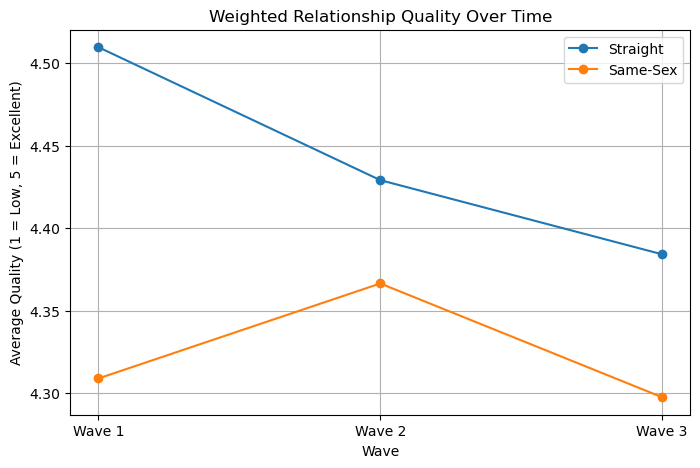

In [234]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for group in group_means_weighted.index:
    plt.plot(
        ["Wave 1", "Wave 2", "Wave 3"],
        group_means_weighted.loc[group],
        marker="o",
        label=group
    )

plt.title("Weighted Relationship Quality Over Time")
plt.xlabel("Wave")
plt.ylabel("Average Quality (1 = Low, 5 = Excellent)")
plt.legend()
plt.grid()
plt.show()

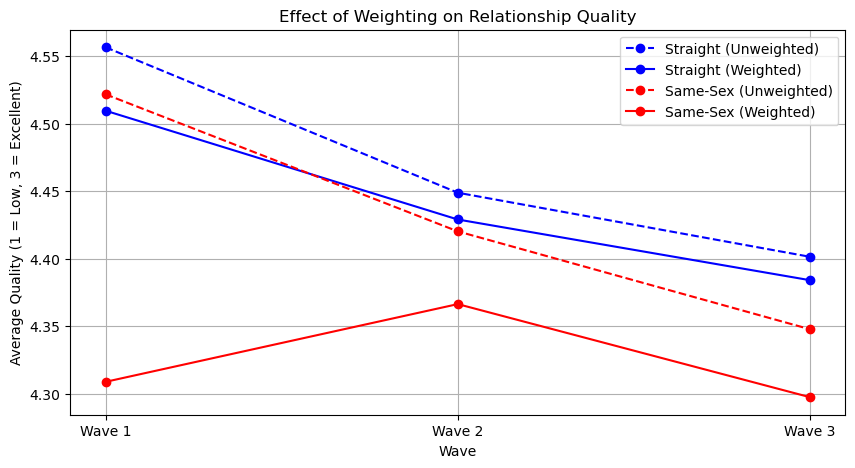

In [233]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

waves = ["Wave 1", "Wave 2", "Wave 3"]

# Define colors
colors = {
    "Straight": "blue",
    "Same-Sex": "red"
}

# Straight
plt.plot(
    waves,
    group_means_unweighted.loc["Straight"],
    marker="o",
    linestyle="--",
    color=colors["Straight"],
    label="Straight (Unweighted)"
)

plt.plot(
    waves,
    group_means_weighted.loc["Straight"],
    marker="o",
    linestyle="-",
    color=colors["Straight"],
    label="Straight (Weighted)"
)

# Same-Sex
plt.plot(
    waves,
    group_means_unweighted.loc["Same-Sex"],
    marker="o",
    linestyle="--",
    color=colors["Same-Sex"],
    label="Same-Sex (Unweighted)"
)

plt.plot(
    waves,
    group_means_weighted.loc["Same-Sex"],
    marker="o",
    linestyle="-",
    color=colors["Same-Sex"],
    label="Same-Sex (Weighted)"
)

plt.title("Effect of Weighting on Relationship Quality")
plt.xlabel("Wave")
plt.ylabel("Average Quality (1 = Low, 3 = Excellent)")
plt.legend()
plt.grid()
plt.show()

In [182]:
df_ss = df_time[df_time["group"] == "Same-Sex"].copy()

df_ss["change_w2"] = df_ss["w2_num"] - df_ss["w1_num"]

In [186]:
print(df_ss["w2_fight"].value_counts())

w2_fight
0 times (no arguments or fights)       40
we argued or fought once               19
we argued or fought 3 times             5
we argued or fought twice               4
we argued or fought 5 times             1
we argued or fought 4 times             0
we argued or fought 6 times             0
we argued or fought 7 times or more     0
Name: count, dtype: int64


In [187]:
import re

def extract_fight_count(x):
    if pd.isna(x):
        return np.nan
    
    if "0 times" in x:
        return 0
    elif "once" in x:
        return 1
    elif "twice" in x:
        return 2
    else:
        match = re.search(r'\d+', x)
        return int(match.group()) if match else np.nan

df_ss["w2_fight_num"] = df_ss["w2_fight"].apply(extract_fight_count)

In [188]:
print(df_ss[["w2_fight", "w2_fight_num"]].head(10))

                             w2_fight w2_fight_num
193  0 times (no arguments or fights)            0
743          we argued or fought once            1
757  0 times (no arguments or fights)            0
762          we argued or fought once            1
800          we argued or fought once            1
801          we argued or fought once            1
803  0 times (no arguments or fights)            0
815  0 times (no arguments or fights)            0
827  0 times (no arguments or fights)            0
847  0 times (no arguments or fights)            0


In [198]:
print(df_ss[["change_w2", "w2_fight_num"]].corr())
print(df_ss.groupby("w2_fight_num")["change_w2"].mean())

              change_w2  w2_fight_num
change_w2      1.000000     -0.180735
w2_fight_num  -0.180735      1.000000
w2_fight_num
0    0.000000
1   -0.263158
2    0.000000
3   -0.400000
4         NaN
5    0.000000
6         NaN
7         NaN
Name: change_w2, dtype: float64


C:\Users\mdmah\AppData\Local\Temp\ipykernel_44608\208178576.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_ss.groupby("w2_fight_num")["change_w2"].mean())


In [199]:
df_ss.groupby("w2_coronavirus_effect_combo")["change_w2"].mean()

C:\Users\mdmah\AppData\Local\Temp\ipykernel_44608\1922104147.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_ss.groupby("w2_coronavirus_effect_combo")["change_w2"].mean()


w2_coronavirus_effect_combo
better rel than before   -0.153846
no change                -0.076923
worse rel than before    -0.250000
Name: change_w2, dtype: float64

In [200]:
# Compare weighted vs unweighted change
print("Unweighted mean change:", df_ss["change_w2"].mean())

print("Weighted mean change:", np.average(
    df_ss["change_w2"],
    weights=df_ss["w3_attrition_adj_weight"]
))

Unweighted mean change: -0.10144927536231885
Weighted mean change: 0.057542204639436746


In [201]:
df_ss[["change_w2", "w3_attrition_adj_weight"]].corr()

,change_w2,w3_attrition_adj_weight
change_w2,1.000000,0.257606
w3_attrition_adj_weight,0.257606,1.000000
